First 5 Rows:
                             Comment Sentiment
0          Storage capacity is 128GB   Neutral
1              Bought it during sale   Neutral
2  Very disappointed with the camera  Negative
3              Great value for money  Positive
4         Display size is 6.7 inches   Neutral

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Comment    300 non-null    str  
 1   Sentiment  300 non-null    str  
dtypes: str(2)
memory usage: 4.8 KB
None

Dataset Description:
                          Comment Sentiment
count                         300       300
unique                         30         3
top     Excellent user experience   Neutral
freq                           14       100

Accuracy Score:
1.0

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        30
     Ne

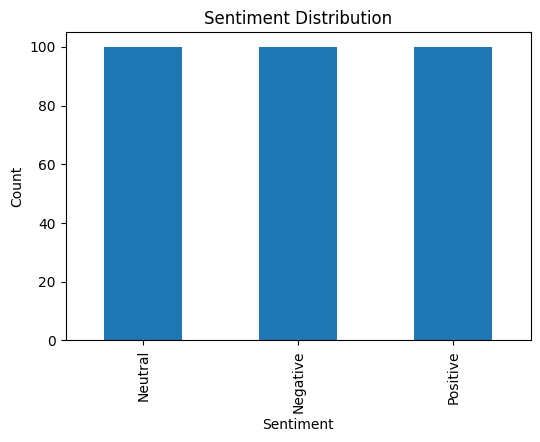


Future Predictions:
Review: Excellent camera and battery
Predicted Sentiment: Positive
--------------------------------------------------
Review: Very poor performance
Predicted Sentiment: Negative
--------------------------------------------------
Review: Phone delivered today
Predicted Sentiment: Neutral
--------------------------------------------------
Review: Screen was bad
Predicted Sentiment: Negative
--------------------------------------------------
Review: Amazing display and fast charging
Predicted Sentiment: Positive
--------------------------------------------------
Review: Battery drains quickly
Predicted Sentiment: Negative
--------------------------------------------------



Enter a phone review (or type 'exit'):  Great camera


Predicted Sentiment: Positive


In [ ]:

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv(
    'https://github.com/YBIFoundation/ProjectDataSet/raw/main/SentimentAnalysisTechNovaMobile.csv'
)

# Display Dataset Information
print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nDataset Description:")
print(df.describe())

# Features and Target
X = df['Comment']
y = df['Sentiment']

# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    stratify=y,
    random_state=2529
)

# TF-IDF Vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# Logistic Regression Model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_vec, y_train)

# Prediction

y_pred = model.predict(X_test_vec)

# Model Evaluation

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Sentiment Distribution Graph

plt.figure(figsize=(6,4))
df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# Future Predictions

new_comments = [
    "Excellent camera and battery",
    "Very poor performance",
    "Phone delivered today",
    "Screen was bad",
    "Amazing display and fast charging",
    "Battery drains quickly"
]

new_comments_vec = tfidf.transform(new_comments)

predictions = model.predict(new_comments_vec)

print("\nFuture Predictions:")
for review, sentiment in zip(new_comments, predictions):
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}")
    print("-"*50)

# User Input Prediction


while True:

    review = input("\nEnter a phone review (or type 'exit'): ")

    if review.lower() == 'exit':
        break

    review_vec = tfidf.transform([review])

    prediction = model.predict(review_vec)

    print("Predicted Sentiment:", prediction[0])

print("\nProgram Ended")